# Day 07｜Activation Patching: Can we control model behavior from inside the black box?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HowardHsuuu/mech-interp-ironman-series/blob/main/notebooks/day07_activation_patching.ipynb)

We use **Qwen2.5-0.5B**, **TransformerLens**, and **activation patching**. The experiment changes one country in a factual-recall prompt, then patches a clean internal activation into the corrupted run to test whether the model's answer moves from `Taipei` back toward `Tokyo`.

## 1. Setup

In [1]:
%env PIP_DISABLE_PIP_VERSION_CHECK=1
%pip install -q "transformer-lens==2.18.0" "transformers==4.57.6" "matplotlib==3.10.8"


env: PIP_DISABLE_PIP_VERSION_CHECK=1


Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformer_lens import HookedTransformer

MODEL_NAME = "Qwen/Qwen2.5-0.5B"
CLEAN_PROMPT = "The capital of Japan is"
CORRUPTED_PROMPT = "The capital of Taiwan is"
CLEAN_ANSWER = " Tokyo"
CORRUPTED_ANSWER = " Taipei"
HOOK_POINT = "resid_pre"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 2. Load and freeze Qwen2.5-0.5B

In [3]:
print("Loading Qwen2.5-0.5B with TransformerLens...")
model = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
model.eval()

for parameter in model.parameters():
    parameter.requires_grad_(False)

print(f"Model: {MODEL_NAME}")
print(f"Transformer blocks: {model.cfg.n_layers}")
print(f"Residual-stream width: {model.cfg.d_model}")
print("Model parameters frozen:", not any(p.requires_grad for p in model.parameters()))

`torch_dtype` is deprecated! Use `dtype` instead!


Loading Qwen2.5-0.5B with TransformerLens...


Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer
Model: Qwen/Qwen2.5-0.5B
Transformer blocks: 24
Residual-stream width: 896
Model parameters frozen: True


## 3. Create a clean run and a corrupted run

The two prompts differ at exactly one token:

```text
Clean:     The capital of Japan  is → Tokyo
Corrupted: The capital of Taiwan is → Taipei
```

Here, *corrupted* does not mean that the model answers incorrectly. We deliberately change the input so the model produces a different behavior. Keeping the token sequences aligned lets us patch the activation at the same layer and position between runs.

In [4]:
clean_tokens = model.to_tokens(CLEAN_PROMPT)
corrupted_tokens = model.to_tokens(CORRUPTED_PROMPT)

assert clean_tokens.shape == corrupted_tokens.shape

clean_str_tokens = model.to_str_tokens(clean_tokens[0])
corrupted_str_tokens = model.to_str_tokens(corrupted_tokens[0])

token_table = pd.DataFrame(
    {
        "Position": np.arange(clean_tokens.shape[1]),
        "Clean token": clean_str_tokens,
        "Corrupted token": corrupted_str_tokens,
        "Changed?": [a != b for a, b in zip(clean_str_tokens, corrupted_str_tokens)],
    }
)

print("Clean prompt:", CLEAN_PROMPT)
print("Corrupted prompt:", CORRUPTED_PROMPT)
display(token_table)

Clean prompt: The capital of Japan is
Corrupted prompt: The capital of Taiwan is


,Position,Clean token,Corrupted token,Changed?
0,0,The,The,False
1,1,capital,capital,False
2,2,of,of,False
3,3,Japan,Taiwan,True
4,4,is,is,False


## 4. Verify that the model's behavior changes

We measure behavior with the logit difference

```text
logit(" Tokyo") − logit(" Taipei")
```

Positive values favor the clean answer; negative values favor the corrupted answer. The exact prompt may assign a generic continuation the highest probability, so this metric focuses on the model's relative preference between the two factual answers.

In [5]:
clean_answer_id = model.to_single_token(CLEAN_ANSWER)
corrupted_answer_id = model.to_single_token(CORRUPTED_ANSWER)


def logit_diff_metric(logits):
    return (
        logits[0, -1, clean_answer_id]
        - logits[0, -1, corrupted_answer_id]
    ).item()


def top_predictions(logits, run, k=5):
    final_logits = logits[0, -1]
    probabilities = final_logits.softmax(dim=-1)
    top_probs, top_ids = torch.topk(probabilities, k=k)
    return pd.DataFrame(
        {
            "Run": run,
            "Rank": np.arange(1, k + 1),
            "Token": [repr(model.to_single_str_token(int(token_id))) for token_id in top_ids],
            "Probability": top_probs.detach().cpu().numpy(),
        }
    )


with torch.inference_mode():
    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

clean_metric = logit_diff_metric(clean_logits)
corrupted_metric = logit_diff_metric(corrupted_logits)

baseline_summary = pd.DataFrame(
    [
        {"Run": "Clean", "Logit difference": clean_metric},
        {"Run": "Corrupted", "Logit difference": corrupted_metric},
    ]
)

display(baseline_summary.round(3))
display(
    pd.concat(
        [
            top_predictions(clean_logits, "Clean"),
            top_predictions(corrupted_logits, "Corrupted"),
        ],
        ignore_index=True,
    ).round({"Probability": 4})
)

,Run,Logit difference
0,Clean,7.472
1,Corrupted,-5.640


,Run,Rank,Token,Probability
0,Clean,1,' __',0.2162
1,Clean,2,' located',0.1051
2,Clean,3,' Tokyo',0.0670
3,Clean,4,' ____',0.0594
4,Clean,5,' ______',0.0495
5,Corrupted,1,' located',0.1430
6,Corrupted,2,' __',0.1136
7,Corrupted,3,' known',0.0919
8,Corrupted,4,' ______',0.0692
9,Corrupted,5,' ____',0.0625


## 5. Patch one internal activation

We now keep the **corrupted Taiwan prompt** as the model's input, but replace one residual-stream activation with the corresponding activation saved from the clean Japan run:

```text
clean activation at one layer and position
                    ↓
corrupted forward pass → patched prediction
```

Following the article's example, the single demonstration patches the country-token position at layer 8, before transformer block 8.

In [6]:
def normalized_restoration(metric_value):
    return (metric_value - corrupted_metric) / (clean_metric - corrupted_metric)


def run_residual_patch(base_tokens, source_cache, layer, position):
    hook_name = f"blocks.{layer}.hook_{HOOK_POINT}"

    def patch_hook(activation, hook):
        activation[:, position, :] = source_cache[hook_name][:, position, :]
        return activation

    with torch.inference_mode():
        return model.run_with_hooks(
            base_tokens,
            fwd_hooks=[(hook_name, patch_hook)],
        )


PATCH_LAYER = 8
PATCH_POSITION = clean_str_tokens.index(" Japan")

patched_logits = run_residual_patch(
    corrupted_tokens,
    clean_cache,
    layer=PATCH_LAYER,
    position=PATCH_POSITION,
)
patched_metric = logit_diff_metric(patched_logits)
patched_restoration = normalized_restoration(patched_metric)

single_patch_summary = pd.DataFrame(
    [
        {"Run": "Clean", "Logit difference": clean_metric, "Normalized restoration": 1.0},
        {"Run": "Corrupted", "Logit difference": corrupted_metric, "Normalized restoration": 0.0},
        {"Run": "Patched", "Logit difference": patched_metric, "Normalized restoration": patched_restoration},
    ]
)

print(f"Input remains corrupted: {CORRUPTED_PROMPT!r}")
print(
    f"Patched activation: layer {PATCH_LAYER}, position {PATCH_POSITION} "
    f"({corrupted_str_tokens[PATCH_POSITION]!r})"
)
display(single_patch_summary.round(3))
display(top_predictions(patched_logits, "Patched").round({"Probability": 4}))

Input remains corrupted: 'The capital of Taiwan is'
Patched activation: layer 8, position 3 (' Taiwan')


,Run,Logit difference,Normalized restoration
0,Clean,7.472,1.000
1,Corrupted,-5.640,0.000
2,Patched,7.327,0.989


,Run,Rank,Token,Probability
0,Patched,1,' __',0.2095
1,Patched,2,' located',0.1436
2,Patched,3,' Tokyo',0.0570
3,Patched,4,' ____',0.0509
4,Patched,5,' the',0.0501


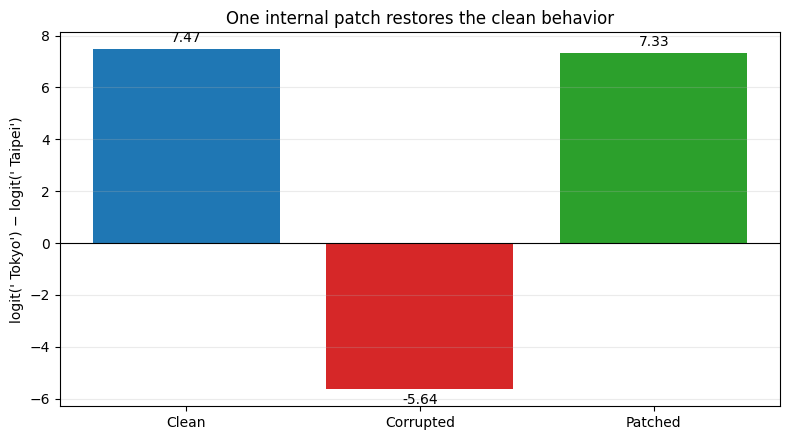

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    single_patch_summary["Run"],
    single_patch_summary["Logit difference"],
    color=["tab:blue", "tab:red", "tab:green"],
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("One internal patch restores the clean behavior")
ax.set_ylabel(f"logit({CLEAN_ANSWER!r}) − logit({CORRUPTED_ANSWER!r})")
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## 6. Sweep every layer and token position

The single patch was selected for a clear demonstration. To search systematically, we patch every `layer × position` residual state and compute

```text
(patched metric − corrupted metric) / (clean metric − corrupted metric)
```

`0` means no restoration beyond the corrupted run, while `1` means clean-level restoration. Values may fall outside this range.

In [8]:
n_layers = model.cfg.n_layers
n_positions = corrupted_tokens.shape[1]
patch_restoration = np.zeros((n_layers, n_positions))

for layer in range(n_layers):
    for position in range(n_positions):
        sweep_logits = run_residual_patch(
            corrupted_tokens,
            clean_cache,
            layer=layer,
            position=position,
        )
        patch_restoration[layer, position] = normalized_restoration(
            logit_diff_metric(sweep_logits)
        )

best_layer, best_position = np.unravel_index(
    np.argmax(patch_restoration),
    patch_restoration.shape,
)

print(f"Best normalized restoration: {patch_restoration[best_layer, best_position]:.3f}")
print(f"Best layer: {best_layer}")
print(f"Best position: {best_position} ({corrupted_str_tokens[best_position]!r})")

Best normalized restoration: 1.007
Best layer: 22
Best position: 4 (' is')


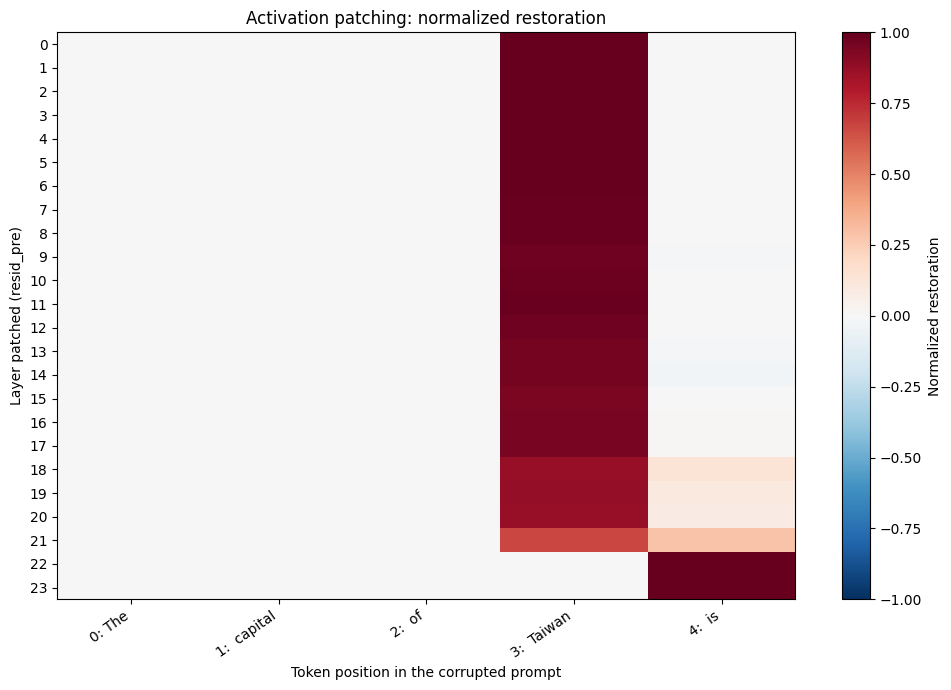

In [9]:
x_labels = [f"{position}: {token}" for position, token in enumerate(corrupted_str_tokens)]

fig, ax = plt.subplots(figsize=(10, 7))
image = ax.imshow(patch_restoration, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("Activation patching: normalized restoration")
ax.set_xlabel("Token position in the corrupted prompt")
ax.set_ylabel(f"Layer patched ({HOOK_POINT})")
ax.set_xticks(np.arange(n_positions))
ax.set_xticklabels(x_labels, rotation=35, ha="right")
ax.set_yticks(np.arange(n_layers))
ax.set_yticklabels(np.arange(n_layers))
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Normalized restoration")
fig.tight_layout()
plt.show()

Two patterns are visible in the sweep:

- Patching the changed country-token position across early and middle layers restores the clean factual preference.
- Patching the final ` is` position in the last layers also restores the clean preference, after answer-relevant information has moved to the prediction position.

A successful patch shows that this activation is sufficient to change the measured behavior under this intervention. It does not by itself identify the complete mechanism that produced the activation.

## 7. Reverse the intervention

The reverse experiment patches the corrupted activation into the clean run. If the same internal state matters causally, this **noising patch** should damage the clean behavior.

In [10]:
noised_logits = run_residual_patch(
    clean_tokens,
    corrupted_cache,
    layer=PATCH_LAYER,
    position=PATCH_POSITION,
)
noised_metric = logit_diff_metric(noised_logits)

noising_summary = pd.DataFrame(
    [
        {"Run": "Clean", "Logit difference": clean_metric},
        {"Run": "Clean + corrupted activation", "Logit difference": noised_metric},
        {"Run": "Corrupted", "Logit difference": corrupted_metric},
    ]
)

display(noising_summary.round(3))
display(top_predictions(noised_logits, "Noised").round({"Probability": 4}))

,Run,Logit difference
0,Clean,7.472
1,Clean + corrupted activation,-5.571
2,Corrupted,-5.640


,Run,Rank,Token,Probability
0,Noised,1,' __',0.1104
1,Noised,2,' located',0.1065
2,Noised,3,' ______',0.0933
3,Noised,4,' known',0.0768
4,Noised,5,' Taipei',0.0728


## 8. Try another intervention

Change one thing at a time:

1. Change `PATCH_LAYER` or `PATCH_POSITION`.
2. Patch `resid_post` instead of `resid_pre`.
3. Replace `Japan/Taiwan` with another factual-recall pair whose token sequences stay aligned.
4. Track one target logit instead of the two-answer logit-difference metric used here.